# t-Spacing Test for Tensors: The 3-Way, 3-Dimensional Case
## Low Rank Tensors
This Jupyter Notebook illustrates the method of testing for the existence of **low-rank tensors** within a noisy observation, represented as $\bf Y$. The alternative hypothesis, which presumes a rank of one, is defined as follows:

$$
\begin{equation}
\tag{$\mathbb H_1(\lambda_0,t_0)$}
 \mathbf{Y} = \mathbf{W} + \lambda_0 \mathbf{t_0}^{\otimes 3}\,,
\end{equation}
$$

Here, $\mathbf{W}\in\mathbb R^{3\times 3\times 3}$ is a symmetric, centered Gaussian 3-way tensor, $\lambda_0>0$ is an eigenvalue, and $\mathbf{t_0}\in\mathbb S^{2}$ is an eigenvector. The goal is to calculate the **spacing** between the first $\lambda_1$ and second $\lambda_2$ *eigenvalues* of $\bf Y$. 

While our procedure is not specifically designed to detect low rank structures, it is applicable to **ALL** alternatives. However, it is particularly powerful when applied to low rank alternatives.

## Reference
This notebook is inspired by the following article:
> [1] Azaïs J.-M., Dalmao F., De Castro Y., *Second maximum of a Gaussian random field and exact (t-)spacing test*, arXiv:.

The code used in this notebook can be found in the following GitHub repository:
> [Tensor Spacing on GitHub](https://github.com/ydecastro/tensor-spacing)

# Presentation of the testing procedure under the null $\lambda_0=0$

## Introduction

We begin by importing some standard Python libraries.

In [1]:
# statistics toolbox: normal, student and chi2 laws for the null distribution
from scipy.stats import norm, t, chi2

# Gamma function for the volume of the sphere
from scipy.special import gamma

# numpy with autograd (automatic differentiation) -- autograd is not really necessary here, look at grad_X function.
import autograd.numpy as np
from autograd import elementwise_grad as egrad

# seaborn and matplotlib for nice displays
import seaborn as sb
sb.set_theme(context="paper", style="white", rc={"figure.dpi": 150, "savefig.dpi": 150})

import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

from matplotlib import cm

# progress bar
from tqdm import tqdm

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

# inline plots
%matplotlib inline

# some useful functions
def cdf_dist_null(z):
    # compute normalized distance between points u and v from the scalar product
    #
    # IF u is fixed and v is uniformly chosen on the sphere
    # THEN cdf_dist_null(z) follows a uniform distribution
    # it can be interpreted as the CDF of the r.v. z when u is fixed and v=t_1,
    # the maximum of the Random Field under the null hypothesis (lambda_0=0)
    #
    # z=<u,v>
    # 0 means that u = v
    # 1 means that u = -v
    # 1/2 means that u and v are orthogonal
    primitive = (1-z)/2
    return primitive # uniform distribution

def scalar_prod(u,v):
    return np.dot(np.transpose(u),v) # scalar product

def color_val(val):
    # fcolors values are used to display a color map on the sphere
    # fcolors are between -1 and 1
    # fcolors = 0 corresponds to the zero level set of the random field
    min_val = np.min(val)
    max_val = np.max(val)
    val_pos = (np.where(val>0, val, 0)/max_val)
    val_neg = (np.where(val<0, val, 0)/(-min_val))
    fcolors = val_neg+val_pos
    return fcolors # color map

We work on the $2$-dimensional Euclidean sphere `d=2`, namely the eigenvector $t_0\in\mathbb S^2$. We consider the space of $3$-way symmetric tensors of dimension $3$, namely the observation $\mathbf{Y}\in\mathbb R^{3\times 3\times 3}$, which has dimension `m=10`. As explained in [1], the variance will be estimated on a space of dimension $\bar{m}=7$.

In [2]:
d = 2
m = 10
m_bar = 7
rv = t(m-1)  # for the student distribution with m-1 degrees of freedom
rv2 = t(m-3) # for the student distribution with m-3 degrees of freedom


## One instance
### Rank one alternatives

We are given a random symmetric tensor $\mathbf{Y}$ such that
$$\mathbb E[\mathbf{Y}]=\lambda_0 \mathbf{t_0}^{\otimes 3}$$

In [3]:
# Parameters for the alternative hypothesis H_1(lambda_0, t_0)
lambda_0 = 0  # eigenvalue (0 = null hypothesis)
t_0 = np.array([0, 0, 1])  # eigenvector (north pole)
x_0, y_0, z_0 = t_0

### The null hypothesis: $Y=\sigma W$

The space of $3$-way symmetric tensors of dimension $3$ has dimension $m=10$ ($3$ principal diagonal terms, $6$ sub-diagonal terms, and $1$ off-diagonal term). The noise tensor $\bf W$ is given by
$$
\begin{align*}
W_{iii} &\text{ of variance } \sigma^2\,; \text{ there are } 3 \text{ principal diagonal terms}, i\in[3] \\
 W_{iij} &\text{ of variance } \sigma^2/3\,;\text{ there are } 6 \text{ sub-diagonal terms}, i\neq j\in[3]\\
W_{123} &\text{ of variance } \sigma^2/6\,;\text{ there is }  1 \text{ off-diagonal term},
\end{align*}
$$
where $\sigma>0$ is the standard deviation of the noise.

The eigenvectors $t\in\mathbb S^2$ are vectors of dimension $3$ and unit Euclidean norm, *i.e.,* points of the $2$-Sphere. As we will see, the estimation of the variance $\sigma^2$ will be done on $\bar m =7$ degrees of freedom.

In [4]:
# Seed for reproducibility
np.random.seed(seed=3141)

def create_tensor(lambda_0, x_0, y_0, z_0):
    # Initialize a Gaussian vector of size m
    gaussian_vector = np.random.normal(size=m)

    # Initialize a 3x3x3 tensor W
    tensor_shape = (3, 3, 3)
    W = np.zeros(tensor_shape)

    # Diagonal values of the tensor 
    diagonal_values = gaussian_vector[:3] + lambda_0 * np.array([x_0**3, y_0**3, z_0**3])
    np.fill_diagonal(W, diagonal_values)

    # Sub-diagonal values of the tensor
    W[0, 0, 1]=gaussian_vector[3]/np.sqrt(3)+lambda_0*x_0*x_0*y_0
    W[0, 1, 0]=gaussian_vector[3]/np.sqrt(3)+lambda_0*x_0*x_0*y_0
    W[1, 0, 0]=gaussian_vector[3]/np.sqrt(3)+lambda_0*x_0*x_0*y_0
    W[0, 0, 2]=gaussian_vector[4]/np.sqrt(3)+lambda_0*x_0*x_0*z_0
    W[0, 2, 0]=gaussian_vector[4]/np.sqrt(3)+lambda_0*x_0*x_0*z_0
    W[2, 0, 0]=gaussian_vector[4]/np.sqrt(3)+lambda_0*x_0*x_0*z_0
    W[1, 1, 0]=gaussian_vector[5]/np.sqrt(3)+lambda_0*y_0*y_0*x_0
    W[1, 0, 1]=gaussian_vector[5]/np.sqrt(3)+lambda_0*y_0*y_0*x_0
    W[0, 1, 1]=gaussian_vector[5]/np.sqrt(3)+lambda_0*y_0*y_0*x_0
    W[1, 1, 2]=gaussian_vector[6]/np.sqrt(3)+lambda_0*y_0*y_0*z_0
    W[1, 2, 1]=gaussian_vector[6]/np.sqrt(3)+lambda_0*y_0*y_0*z_0
    W[2, 1, 1]=gaussian_vector[6]/np.sqrt(3)+lambda_0*y_0*y_0*z_0
    W[2, 2, 0]=gaussian_vector[7]/np.sqrt(3)+lambda_0*z_0*z_0*x_0
    W[2, 0, 2]=gaussian_vector[7]/np.sqrt(3)+lambda_0*z_0*z_0*x_0
    W[0, 2, 2]=gaussian_vector[7]/np.sqrt(3)+lambda_0*z_0*z_0*x_0
    W[2, 2, 1]=gaussian_vector[8]/np.sqrt(3)+lambda_0*z_0*z_0*y_0
    W[2, 1, 2]=gaussian_vector[8]/np.sqrt(3)+lambda_0*z_0*z_0*y_0
    W[1, 2, 2]=gaussian_vector[8]/np.sqrt(3)+lambda_0*z_0*z_0*y_0

    # Off-diagonal values of the tensor
    off_diag_values = gaussian_vector[9] / np.sqrt(6) + lambda_0 * x_0 * y_0 * z_0
    W[0, 1, 2] = W[0, 2, 1] = W[1, 0, 2] = W[1, 2, 0] = W[2, 0, 1] = W[2, 1, 0] = off_diag_values
    return W

W = create_tensor(lambda_0,x_0,y_0,z_0) # Create the tensor W

### Eigenvalue as the maximum of some homogeneous polynomial on the sphere

For a unit norm vector $t=(t^1,t^2,t^3)$, we define 
$$\begin{align*}
\psi_t &:= t^{\otimes 3} =(t^i t^j t^k)_{1\leq i,j,k\leq 3}\\
X(t) &:= \langle \mathbf{W},\psi_t\rangle_E=\sum_{ijk} t^i t^j t^k W_{ijk}
\end{align*}
$$
Observe that $X(\cdot)$ is a homogeneous polynomial of degree $3$. Its maximum $\lambda_1$ is the eigenvalue of $\mathbf{W}$, and its argument maximum $t_1$ is the eigenvector of $\mathbf{W}$. 

To compute $(\lambda_1,t_1)$ we first compute a warm start from a grid of `res` points. 


In [5]:
# Number of points in the grid on the sphere (recommended: 256 (fast) 512 or 1024 (slow))
res = 256

def create_mesh(res):
    # Angles of the mesh grid on the sphere (phi and theta) 
    phi = np.linspace(0, np.pi, res)
    theta = np.linspace(0, 2 * np.pi, res)
    phi, theta = np.meshgrid(phi, theta) # Create the mesh grid

    # Compute Cartesian coordinates of points on the unit sphere from the angles phi and theta 
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    return x, y, z, phi, theta # Return the Cartesian coordinates and the angles

x, y, z, phi, theta = create_mesh(res) # Create the mesh grid on the sphere

We find the maximum `val` on the grid and its argument maximum `t_1_grid`.

In [6]:
def compute_val_and_max_mesh(W, x, y, z):
    # Evaluate X(t) = <W, t^{otimes 3}> on the mesh grid
    val = (
        W[0, 0, 0] * (x**3) +
        W[1, 1, 1] * (y**3) +
        W[2, 2, 2] * (z**3) +
        6 * W[0, 1, 2] * (x * y * z) +
        3 * (
            W[0, 0, 1] * (x**2 * y) +
            W[0, 0, 2] * (x**2 * z) +
            W[1, 1, 0] * (y**2 * x) +
            W[1, 1, 2] * (y**2 * z) +
            W[2, 2, 0] * (z**2 * x) +
            W[2, 2, 1] * (z**2 * y)
        )
    )

    # Find the grid maximum and its index
    ind = np.unravel_index(np.argmax(val, axis=None), val.shape)

    # Convert the grid maximum to a 3D unit vector
    t_1 = np.array([
        np.sin(phi[ind]) * np.cos(theta[ind]),
        np.sin(phi[ind]) * np.sin(theta[ind]),
        np.cos(phi[ind])
    ]).reshape((3, 1))

    t_1_grid = t_1
    return val, t_1_grid, ind

val, t_1_grid, ind = compute_val_and_max_mesh(W, x, y, z)
print("The maximum on the grid is", val[ind], "at point", t_1_grid)

The maximum on the grid is 1.384059493423758 at point [[-0.26003255]
 [-0.38211975]
 [ 0.88677369]]


### Gradient and Hessian of the Random Field

We compute the Euclidean gradient $\nabla X(t)$, the Riemannian gradient $\nabla_{\mathbb S^2} X(t) = (I - tt^\top)\nabla X(t)$, and the Riemannian Hessian of $X$ at a point $t\in\mathbb S^2$. These will be used for gradient descent on the sphere and for the computation of the spacing test statistic.

In [7]:
# Calculate the Random Field X for a given parameter vector t  
def X(t):
    X_val = (
        W[0, 0, 0] * (t[0]**3) +
        W[1, 1, 1] * (t[1]**3) +
        W[2, 2, 2] * (t[2]**3) +
        6 * W[0, 1, 2] * (t[0] * t[1] * t[2]) +
        3 * (
            W[0, 0, 1] * (t[0]**2 * t[1]) +
            W[0, 0, 2] * (t[0]**2 * t[2]) +
            W[1, 1, 0] * (t[1]**2 * t[0]) +
            W[1, 1, 2] * (t[1]**2 * t[2]) +
            W[2, 2, 0] * (t[2]**2 * t[0]) +
            W[2, 2, 1] * (t[2]**2 * t[1])
        )
    )
    return X_val # Return the Random Field X value 

# Calculate the gradient of the Random Field X for a given parameter vector t 
def grad_X(t):
    gradient_val = np.zeros(3) # Initialize the gradient value
    gradient_val[0] = (
        6 * (W[0, 1, 2] * t[1] * t[2] + W[0, 0, 2] * t[0] * t[2] + W[0, 0, 1] * t[0] * t[1]) +
        3 * (W[0, 0, 0] * t[0]**2 + W[0, 1, 1] * t[1]**2 + W[0, 2, 2] * t[2]**2)
    ) # Calculate the gradient value for the first component
    gradient_val[1] = (
        6 * (W[1, 1, 2] * t[1] * t[2] + W[1, 0, 2] * t[0] * t[2] + W[1, 0, 1] * t[0] * t[1]) +
        3 * (W[1, 0, 0] * t[0]**2 + W[1, 1, 1] * t[1]**2 + W[1, 2, 2] * t[2]**2)
    ) # Calculate the gradient value for the second component
    gradient_val[2] = (
        6 * (W[2, 1, 2] * t[1] * t[2] + W[2, 0, 2] * t[0] * t[2] + W[2, 0, 1] * t[0] * t[1]) +
        3 * (W[2, 0, 0] * t[0]**2 + W[2, 1, 1] * t[1]**2 + W[2, 2, 2] * t[2]**2)
    ) # Calculate the gradient value for the third component
    return gradient_val # Return the gradient value

# Calculate the same gradient using autodiff
egrad_X = egrad(X) # Calculate the gradient using autodiff

# Calculate the Riemannian gradient of the Random Field X for a given parameter vector t
def grad_riem_X(t):
    Pi = np.dot(t, np.transpose(t))
    temp = np.dot((np.eye(3) - Pi), grad_X(t))
    return temp # Return the Riemannian gradient value

# Define the Hessian matrix of X for a given parameter vector t
def Hess_X(t): # Calculate the Hessian matrix of X for a given parameter vector t
    H = np.zeros(9).reshape((3, 3))
    for i in [0, 1, 2]:
        for j in [0, 1, 2]:
            H[i, j] = 6 * (W[i, j, 0] * t[0] + W[i, j, 1] * t[1] + W[i, j, 2] * t[2])
    return H # Return the Hessian matrix of X for a given parameter vector t

# Calculate the Riemannian Hessian of the Random Field X for a given parameter vector u
def Hess_riem_X(u): # Calculate the Riemannian Hessian of X for a given parameter vector u
    Pi = np.dot(u, np.transpose(u))
    R = np.dot((np.eye(3) - Pi), Hess_X(u))
    R = np.dot(R, (np.eye(3) - Pi))
    R -= np.dot(np.transpose(grad_X(u)), u) * (np.eye(3) - Pi)
    return R # Return the Riemannian Hessian of X for a given parameter vector u

### Gradient Descent on the sphere to find $(\lambda_1, t_1)$

We perform a Riemannian gradient ascent on $\mathbb S^2$: at each step we project the Euclidean gradient onto the tangent space, take a step, and re-normalize to stay on the sphere.

In [8]:
# Gradient descent parameters to find the maximum of the Random Field
step_size = 0.02  # Step size for gradient descent
step_count = 512  # Number of steps in gradient descent (recommended: 512 (fast) 1024 2048 (accurate))

# initiate with maximum on the mesh grid 
t_1 = t_1_grid # Start the GD on the sphere from the maximum point on the grid

# GD on the sphere to find the maximum of the Random Field
for i in range(step_count):
    Pi = np.dot(t_1,np.transpose(t_1))
    gradient = np.dot((np.eye(3)-Pi),egrad_X(t_1))
    t_temp = t_1 + step_size * gradient #gradient descent step
    t_1 = t_temp/np.linalg.norm(t_temp) # Update the point on the sphere
    
lambda_1 = X(t_1) # Compute the maximum of the Random Field
dist = np.dot(np.transpose(t_1),t_0) # Compute the distance between t_1 and t_0
print("The maximum is", lambda_1, "at point", t_1) # Print the maximum value and its argument

The maximum is [1.38409743] at point [[-0.26217431]
 [-0.37770121]
 [ 0.88803515]]


### Riemannian Hessian and the function $G$

We compute the Riemannian Hessian $R$ at the maximum $t_1$. The matrix $R$ is defined by
$$
R := \tfrac{1}{3}\mathrm{Hess}_{\mathbb S^2}X(t_1) + \lambda_1 (I - t_1 t_1^\top) + t_1 t_1^\top\,.
$$
From $R$ we extract its determinant $\det R$ and (reduced) trace $\mathrm{tr}(R)-1$. The function $G(\ell)$ is the expected Euler characteristic of the excursion set $\{t\in\mathbb{S}^2 : X(t)\geq\ell\}$:
$$
G(\ell) = (\ell - \mathrm{tr}R)\,\varphi(\ell) + (\det R + 1)(1-\Phi(\ell))\,,
$$
where $\varphi$ and $\Phi$ are the standard normal pdf and cdf.

In [9]:
# Projection matrix onto the normal space at t_1
Pi = np.dot(t_1, np.transpose(t_1))

# Riemannian Hessian of X at t_1, augmented with the eigenvalue and projection:
#   R = (1/3) Hess_S2 X(t_1) + lambda_1 (I - t_1 t_1^T) + t_1 t_1^T
R = Hess_riem_X(t_1)
R = (1/3) * R + lambda_1 * (np.eye(3) - Pi)
R += Pi  # add projection so that R is a full-rank 3x3 matrix

# Geometric quantities needed for the expected Euler characteristic
detR = np.linalg.det(R)
traceR = np.trace(R) - 1  # reduced trace (subtract the eigenvalue 1 from the projection)

# G(l): expected Euler characteristic of the excursion set {t : X(t) >= l}
# G(l) = (l - tr(R)) * phi(l) + (det(R) + 1) * (1 - Phi(l))
def G(l):
    output = 0
    output += (l - traceR) * norm.pdf(l)
    output += (detR + 1) * (1 - norm.cdf(l))
    return output

# G1 = G(lambda_1): value at the first eigenvalue
G1 = G(lambda_1)

## The Second Eigenvalue and the Regressed Random Field

The Least Angle Regression (LARS) is a forward stepwise variable selection algorithm that generates a sequence $(\lambda_1,t_1)$ of knots. The first knot $(\lambda_1,t_1)$ is the maximum and the argument maximum of the maximal absolute correlation between the observation $Y$ and $\psi_t:=t^\otimes 3$, the features. Therefore, the first step of the LARS aims to maximize 
$$
\lambda_1=\max_t |\langle Y,\psi_t\rangle_E|
\quad
\text{and}
\quad
t_1=\arg\max_{t\in { M}} |\langle Y,\psi_t\rangle_E|\,.
$$
Here, $\max_{t} |Z(t)|=\max_{t} Z(t)$, where $Z(t)=\langle Y,\psi_t\rangle_E$. We define the residual for all $\lambda\leq\lambda_1$ as,
$$
Z^{\lambda}(t):=\langle Y-(\lambda_1-{\lambda})\psi_{t_1},\psi_t\rangle_E=Z(t)-(\lambda_1-{\lambda})c(t,t_1)\,,
$$
where $c(s,t)=\langle \psi_s,\psi_t\rangle$. Again, $\max_{t} |Z^\lambda(t)|=\max_{t} Z^\lambda(t)$. It can be verified that $Z^{\lambda}(t_1)=\lambda$. The second knot is defined by 
$$
\lambda_1-\lambda_2:=\inf\Big\{\varepsilon>0\ :\ \exists t\neq t_1\text{ s.t. }Z^{\lambda_1-\varepsilon}(t)\geq\lambda_1-\varepsilon\Big\}\,.
$$
Next, we compute the regressed random field and its maximum on the grid.

In [10]:
# Calculate the regressed random field X2 for a given parameter vector u 
def X2(u): # Calculate the regressed random field X2 for a given parameter vector u
    # Calculate cst value 
    cst = np.dot(np.transpose(t_1), u)**3 

    # Calculate X2 value 
    X_val = X(u) - cst * X(t_1)
    X_val = X_val / (1 - cst)
    return X_val # Return the regressed random field X2 value

# Calculate the gradient of the regressed random field X2
grad_X2 = egrad(X2) # Calculate the gradient of the regressed random field X2

# Calculate cst_val 
cst_val = (t_1[0] * x + t_1[1] * y + t_1[2] * z)**3 

# Calculate val2 
val2 = val - cst_val * X(t_1)
val2 = val2 / (1 - cst_val) 

# Find the maximum value and its indices on the grid for val2 
ind2 = np.unravel_index(np.argmax(val2, axis=None), val.shape) # Find the indices of the maximum value

# Derive t_2 from the maximum point on the grid for val2 
t_2 = np.array([
    np.sin(phi[ind2]) * np.cos(theta[ind2]),
    np.sin(phi[ind2]) * np.sin(theta[ind2]),
    np.cos(phi[ind2])
]).reshape((3, 1)) # Derive t_2 from the indices

# Assign t_2_grid to t_2 
t_2_grid = t_2 

### Gradient Descent for $(\lambda_2, t_2)$ and the Spacing $p$-value

We find the maximum $(\lambda_2, t_2)$ of the regressed random field $X_2$ on the grid, then refine it with gradient descent. The **spacing** $p$-value is $G(\lambda_1)/G(\lambda_2)$, which is uniformly distributed under $\mathbb H_0$.

In [11]:
# Perform gradient descent to update t_2 iteratively 
for i in range(step_count): 
    # Compute Pi and gradient for t_2
    Pi = np.outer(t_2, t_2) # Compute Pi for t_2
    gradient = np.dot(np.eye(3) - Pi, grad_X2(t_2)) # Compute the gradient for t_2

    # Update t_2 using gradient descent with step_size 
    t_temp = t_2 + step_size * gradient # Update t_2 using gradient descent

    # Normalize t_temp to ensure it remains on the unit sphere 
    t_2 = t_temp / np.linalg.norm(t_temp) # Normalize t_temp to ensure it remains on the unit sphere

# Calculate lambda_2 for the updated t_2 
lambda_2 = X2(t_2) # Compute the maximum of the Regressed Random Field for t_2

# Compute the dot product between t_1 and t_2 
dist2 = np.dot(np.transpose(t_1), t_2) # Compute the distance between t_1 and t_2

# Calculate G2 for lambda_2
G2 = G(lambda_2)

# Compute the spacing p-value
stat = G1 / G2 # Compute the spacing p-value

## Variance Estimation

We estimate the unknown variance $\sigma^2$ from the regressed random field $X_2$. We draw $\bar m=7$ random points on $\mathbb S^2$, compute the variance-covariance matrix $\Sigma$ of $(X_2(v_1),\ldots,X_2(v_{\bar m}))$, and obtain $\hat\sigma$ by whitening. As shown in [1], $\hat\sigma$ does not depend on the particular random points chosen.

In [12]:
def generate_random_points_and_covariance(t_1, m_bar):
    # Calculate the projection matrix Pi
    Pi = np.dot(t_1, np.transpose(t_1)) # Calculate the projection matrix Pi

    # Initialize an array to store random points for variance estimates
    V = np.zeros(3 * m_bar).reshape((3, m_bar)) # Initialize an array to store random points for variance estimates

    # Initialize the variance-covariance matrix Sigma
    Sigma = np.zeros(m_bar**2).reshape((m_bar, m_bar)) # Initialize the variance-covariance matrix Sigma

    # Generate random points for variance estimates and store them in V
    for i in range(m_bar):
        r = norm.rvs(size=3)
        r = r / np.linalg.norm(r) # Normalize the random point
        V[:, i] = r # Store the random point in V

    # Compute the entries of the variance-covariance matrix Sigma
    for i in range(m_bar):
        u = V[:, i] # Get the ith random point
        for j in range(m_bar):
            v = V[:, j] # Get the jth random point

            # Calculate each entry of Sigma
            Sigma[i, j] = (
                scalar_prod(u, v)**3 -
                (scalar_prod(u, t_1)**3) * (scalar_prod(v, t_1)**3) -
                (1/3) * scalar_prod(
                    (3 * (scalar_prod(u, t_1)**2) * np.dot((np.eye(3) - Pi), u)),
                    (3 * (scalar_prod(v, t_1)**2) * np.dot((np.eye(3) - Pi), v))
                )
            ) # Calculate each entry of Sigma
    return V, Sigma # Return the random points and the variance-covariance matrix Sigma 

V, Sigma = generate_random_points_and_covariance(t_1, m_bar) # Generate random points and the variance-covariance matrix Sigma

# Define the Regressed RF for a given parameter vector u
def X22(u):
    # Calculate cst value
    cst = np.dot(np.transpose(t_1), u)**3

    # Calculate X22 value
    X_val = X(u) - cst * X(t_1)
    return X_val

# Initialize an array to store the values of X22 for random points V
X2_V = np.zeros(m_bar)

# Calculate X22 values for each random point in V
for i in range(m_bar):
    X2_V[i] = X22(V[:, i])

### Verification: $\hat\sigma$ is invariant to the random points

We demonstrate numerically that the variance estimate $\hat\sigma$ does **not** depend on the particular random points drawn on the sphere. We run the estimation 10 additional times with fresh random points and verify that the estimate remains constant.

In [13]:
# Variance estimator: whitening approach
# Given the covariance matrix Sigma of (X2(v_1),...,X2(v_{m_bar})),
# compute sigma = || Sigma^{-1/2} X2_V || / sqrt(m_bar)
def std_estimate(Sigma, X2_V, m_bar):
    eigenvalues, eigenvectors = np.linalg.eig(Sigma)
    sqrt_eigen_inv = eigenvectors @ np.diag(1 / np.sqrt(eigenvalues)) @ eigenvectors.T
    normalized_squared_norm = np.linalg.norm(sqrt_eigen_inv @ X2_V)**2 / m_bar
    sigma = np.sqrt(normalized_squared_norm)
    return sigma

sigma = std_estimate(Sigma, X2_V, m_bar)
print("The standard deviation estimate is", sigma)

# Verify invariance: re-run with 10 different sets of random points
for new_run in range(10):
    V_new, Sigma_new = generate_random_points_and_covariance(t_1, m_bar)
    X2_V_new = np.zeros(m_bar)
    for i in range(m_bar):
        X2_V_new[i] = X22(V_new[:, i])
    sigma_new_run = std_estimate(Sigma_new, X2_V_new, m_bar)
    print("The standard deviation estimate for the new run is", sigma_new_run)

The standard deviation estimate is 0.5820878322817061
The standard deviation estimate for the new run is 0.5820878254362816
The standard deviation estimate for the new run is 0.5820878254297096
The standard deviation estimate for the new run is 0.5820878290404479
The standard deviation estimate for the new run is 0.5820878249322264
The standard deviation estimate for the new run is 0.582087825368677
The standard deviation estimate for the new run is 0.5820878252805382
The standard deviation estimate for the new run is 0.5820878253705177
The standard deviation estimate for the new run is 0.5820878253672228
The standard deviation estimate for the new run is 0.5820878254152133
The standard deviation estimate for the new run is 0.5820878253807109


### The function $H$ and the $t$-Spacing $p$-value

The function $H(\ell)$ is the analogue of $G(\ell)$ when the variance $\sigma$ is estimated. It uses Student-$t$ distributions (with $m{-}1=9$ and $m{-}3=7$ degrees of freedom) instead of the Gaussian. The **$t$-spacing** $p$-value is $H(\lambda_1/\hat\sigma)/H(\lambda_2/\hat\sigma)$.

In [14]:
# H(l): analogue of G(l) when sigma is estimated (uses Student-t distributions)
#   rv  = Student-t with m-1 = 9 degrees of freedom
#   rv2 = Student-t with m-3 = 7 degrees of freedom
# The formula involves the Gamma function for the volume constants on the sphere.
def H(l):
    output = detR * (np.sqrt(7/9) * (1 - rv.cdf(l * np.sqrt(9) / np.sqrt(7))))
    output += (-traceR) * ((7 * np.sqrt(7)) / (8 * np.sqrt(9))) * ((gamma(5) * gamma(7/2)) / (gamma(9/2) * gamma(4))) * rv2.pdf(l)
    output += ((7 * np.sqrt(7)) / (8 * np.sqrt(9))) * ((gamma(5) * gamma(7/2)) / (gamma(9/2) * gamma(4))) * (l * rv2.pdf(l) + 1 - rv2.cdf(l))
    return output

# t-spacing p-value: H(lambda_1/sigma) / H(lambda_2/sigma)
stat2 = H(lambda_1/sigma)/H(lambda_2/sigma)

## Visualization: One Instance

### Sphere colored by the random field $X$ with the first eigenvector $t_1$

The sphere $\mathbb S^2$ is colored according to the values of the random field $X(t)$ (Spectral colormap). The black arrow indicates the first eigenvector $t_1$, *i.e.,* the point where $X$ attains its maximum $\lambda_1$.

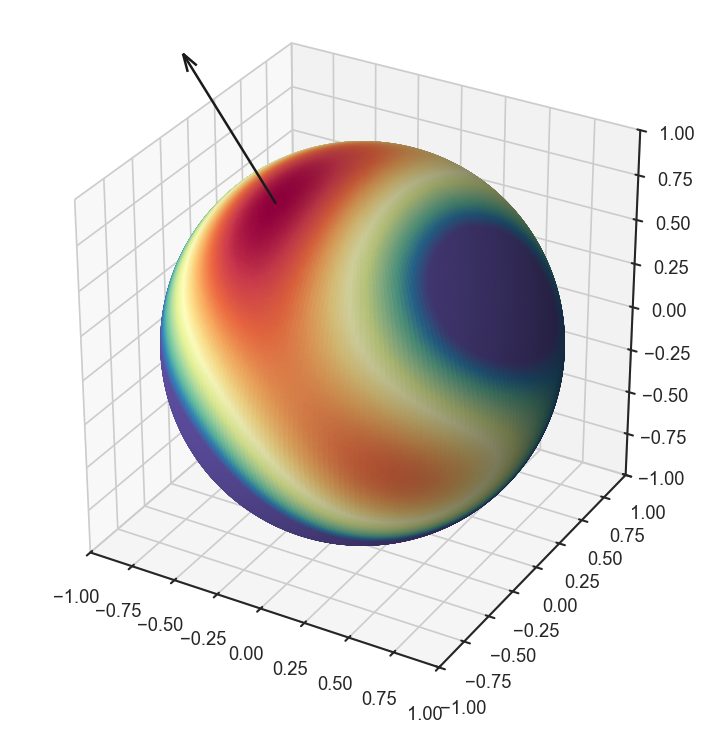

In [15]:
# Set colors for the plot based on the field values
fcolors = color_val(val)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with colored faces
ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=cm.Spectral_r(fcolors))

# Set axis limits and aspect ratio
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_aspect("equal")

# Add a quiver plot to show the gradient at t_1
ax.quiver(
    t_1[0], t_1[1], t_1[2],
    t_1[0] + 0.0001 * grad_X(t_1)[0],
    t_1[1] + 0.0001 * grad_X(t_1)[1],
    t_1[2] + 0.0001 * grad_X(t_1)[2],
    color='k',
    arrow_length_ratio=0.1
)

# Adjust the layout and display the plot
ax.set_facecolor("white")
plt.tight_layout()
fig.savefig("sphere_first_eig",
                bbox_inches='tight', 
                transparent=True,
                pad_inches=0,
                dpi=150)
plt.show()

### Regressed field $X_2$ with both eigenvectors (view from above $t_1$)

The sphere is now colored according to the regressed random field $X_2(t)$. Both eigenvectors $t_1$ and $t_2$ are displayed. The viewpoint is set above $t_1$ to show the position of $t_2$ relative to $t_1$.

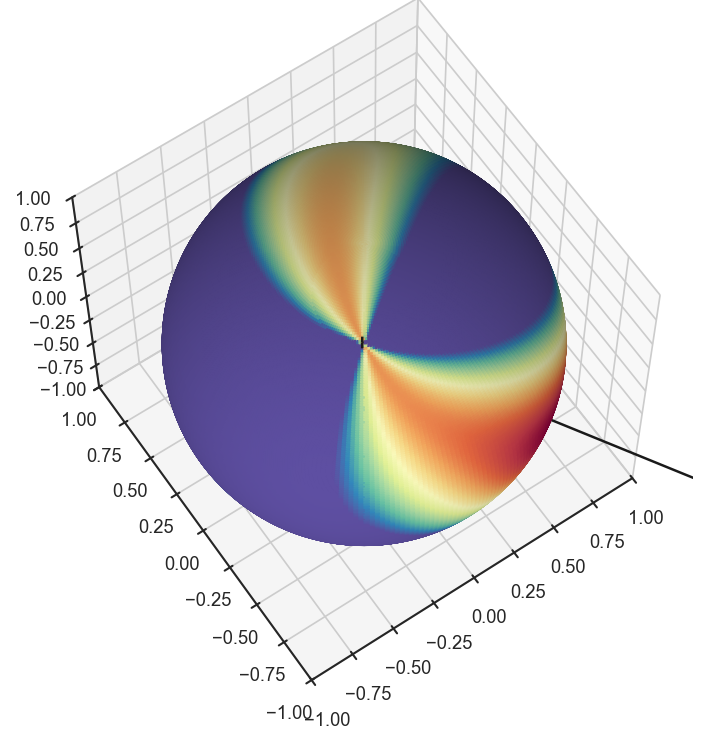

In [16]:
# Calculate colors based on val2
fcolors = color_val(val2)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with colored faces
ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=cm.Spectral_r(fcolors))

# Set axis limits and aspect ratio
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_aspect("equal")

# Set the view angle of the plot
ax.view_init(90 - 180 * phi[ind] / (np.pi), 360 * theta[ind] / (2 * np.pi))

# Add a quiver plot to show the gradient at t_1
ax.quiver(
    t_1[0], t_1[1], t_1[2],
    t_1[0] + 0.001 * grad_X(t_1)[0],
    t_1[1] + 0.001 * grad_X(t_1)[1],
    t_1[2] + 0.001 * grad_X(t_1)[2],
    color='k',
    arrow_length_ratio=0.1
)

# Add a quiver plot to show the gradient at t_2
ax.quiver(
    t_2[0], t_2[1], t_2[2],
    t_2[0] + 0.001 * grad_X2(t_2)[0],
    t_2[1] + 0.001 * grad_X2(t_2)[1],
    t_2[2] + 0.001 * grad_X2(t_2)[2],
    color='k',
    arrow_length_ratio=0.1
)

# Adjust the layout and display the plot
ax.set_facecolor("white")
plt.tight_layout()
fig.savefig("sphere_two_eig_above",
                bbox_inches='tight', 
                transparent=True,
                pad_inches=0,
                dpi=150)
plt.show()


### Regressed field $X_2$ with both eigenvectors (default view)

Same plot as above but from the default viewpoint, showing the spatial arrangement of the two eigenvectors $t_1$ and $t_2$ on the sphere.

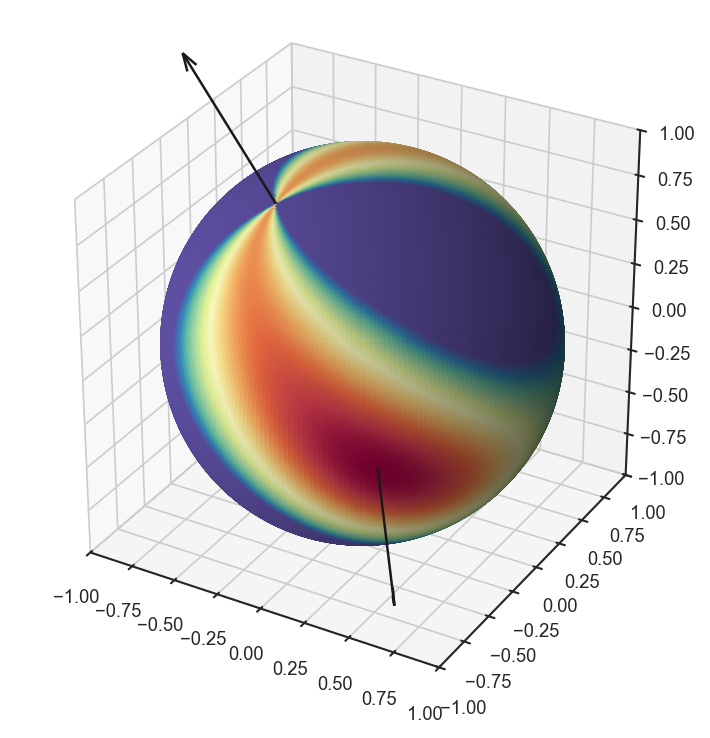

In [17]:
# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with colored faces
ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=cm.Spectral_r(fcolors))

# Set axis limits and aspect ratio
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_aspect("equal")

# Add a quiver plot to show the gradient at t_1
ax.quiver(
    t_1[0], t_1[1], t_1[2],
    t_1[0] + 0.001 * grad_X(t_1)[0],
    t_1[1] + 0.001 * grad_X(t_1)[1],
    t_1[2] + 0.001 * grad_X(t_1)[2],
    color='k',
    arrow_length_ratio=0.1
)

# Add a quiver plot to show the gradient at t_2
ax.quiver(
    t_2[0], t_2[1], t_2[2],
    t_2[0] + 0.001 * grad_X2(t_2)[0],
    t_2[1] + 0.001 * grad_X2(t_2)[1],
    t_2[2] + 0.001 * grad_X2(t_2)[2],
    color='k',
    arrow_length_ratio=0.1
)

# Adjust the layout and display the plot
ax.set_facecolor("white")
plt.tight_layout()
fig.savefig("sphere_two_eig",
                bbox_inches='tight', 
                transparent=True,
                pad_inches=0,
                dpi=150)
plt.show()

### Volumic view: the **helix** structure of $X_2$

The radius of the sphere is modulated by the values of $X_2(t)/\lambda_2$, producing a volumetric deformation. This reveals the characteristic **helix** structure of the regressed random field around the second eigenvector $t_2$.

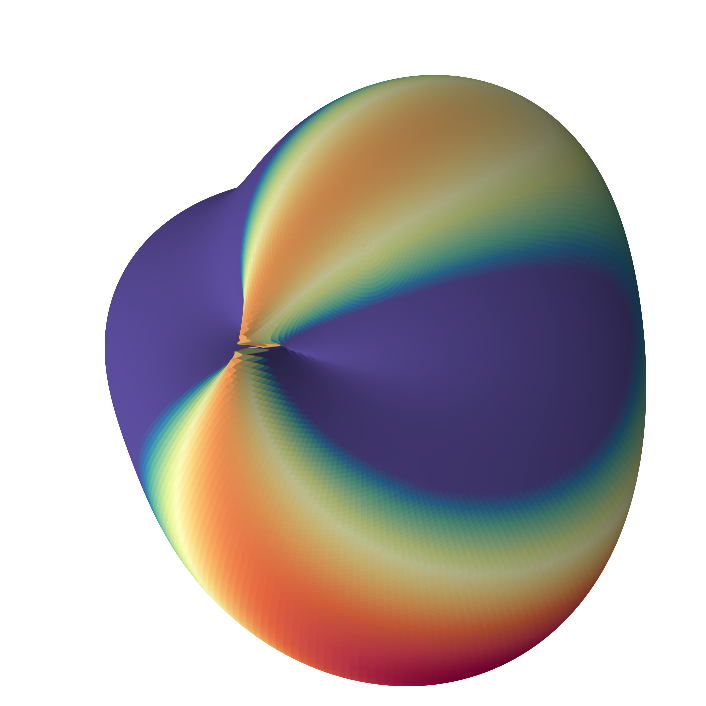

In [18]:
# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with modified colors
ax.plot_surface(
    (1 + 0.3 * val2 / lambda_2) * x,
    (1 + 0.3 * val2 / lambda_2) * y,
    (1 + 0.3 * val2 / lambda_2) * z,
    rstride=1,
    cstride=1,
    facecolors=cm.Spectral_r(fcolors)
)

# Set axis limits and aspect ratio
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_aspect("equal")

# Set the view angle of the plot
ax.view_init(90 - 180 * phi[ind] / (np.pi) + 10,
             360 * theta[ind] / (2 * np.pi) + 50)

# Turn off axis labels and ticks
ax.set_facecolor("white")
plt.axis('off')

# Adjust the layout and display the plot
RADIUS = 1.5  # Control this value.
ax.set_xlim3d(-RADIUS / 2, RADIUS / 2)
ax.set_zlim3d(-RADIUS / 2, RADIUS / 2)
ax.set_ylim3d(-RADIUS / 2, RADIUS / 2)
plt.tight_layout()
fig.savefig('left_volumic_helix.png',
                bbox_inches='tight', 
                transparent=True,
                pad_inches=0,
                dpi=150)
plt.show()

# Monte-Carlo Experiments

We repeat the full testing procedure (tensor generation, eigenvalue extraction by gradient descent, spacing and $t$-spacing $p$-value computation) over many independent realizations. Under $\mathbb H_0$ ($\lambda_0=0$), both $p$-values should be uniformly distributed on $[0,1]$.

In [19]:
# Seed for reproducibility of the MC experiment
np.random.seed(seed=31415)

# Chi-squared distribution with m_bar=7 degrees of freedom (for sigma^2 under H_0)
rv3 = chi2(7)

## MC experiment: `repet=100` independent realizations

We initialize arrays to store the spacing $p$-values, $t$-spacing $p$-values, variance estimates $\hat\sigma$, and distances $d(t_0,t_1)$ and $d(t_1,t_2)$ for each realization.

In [20]:
# Number of MC repetitions
repet = 100

# Spacing test p-values
stat = np.zeros(repet)

# t-Spacing test p-values
stat2 = np.zeros(repet)

# standard error estimates
sigma = np.zeros(repet)

# distance to true eigenvector (for 1-sparse alternatives)
dist = np.zeros(repet)

# distance to first estimated eigenvector
dist2 = np.zeros(repet)

# random points for variance estimates
V = np.zeros(3*m_bar).reshape((3,m_bar))

# Variance-covariance matrix of regressed random field at the random points
Sigma = np.zeros(m_bar**2).reshape((m_bar,m_bar))

In [21]:
# Alternative hypothesis: lambda_0=0 (null), t_0 = north pole
lambda_0 = 0
x_0 = 0
y_0 = 0
z_0 = 1
t_0 = np.array([x_0, y_0, z_0])

In [22]:
# Higher resolution grid for the MC experiment (1024 vs 256 in the single instance)
res = 1024
x, y, z, phi, theta = create_mesh(res)

In [23]:
# Gradient descent parameters to find the maximum of the Random Field
step_size = 0.02
step_count = 256

In [24]:
for k in tqdm(range(repet), desc="MC samples", leave=False, colour='green'):

    # ---- Step 1: Generate a random tensor under H_1(lambda_0, t_0) ----
    W = create_tensor(lambda_0, x_0, y_0, z_0)

    # ---- Step 2: Find the maximum on the mesh grid (warm start) ----
    val, t_1_grid, ind = compute_val_and_max_mesh(W, x, y, z)

    # ---- Step 3: Define the random field and its derivatives for this tensor ----
    def X(t):
        X_val = W[0,0,0]*(t[0]**3) + W[1,1,1]*(t[1]**3) + W[2,2,2]*(t[2]**3)
        X_val += 6*W[0,1,2]*(t[0]*t[1]*t[2])
        X_val += 3*(W[0,0,1]*(t[0]**2*t[1]) + W[0,0,2]*(t[0]**2*t[2]) + W[1,1,0]*(t[1]**2*t[0]) + W[1,1,2]*(t[1]**2*t[2]) + W[2,2,0]*(t[2]**2*t[0]) + W[2,2,1]*(t[2]**2*t[1]));
        return X_val

    def grad_X(t):
        gradient_val = np.zeros(3)
        gradient_val[0] = 6*(W[0,1,2]*t[1]*t[2]+W[0,0,2]*t[0]*t[2]+W[0,0,1]*t[0]*t[1]) + 3*(W[0,0,0]*t[0]**2+W[0,1,1]*t[1]**2+W[0,2,2]*t[2]**2)
        gradient_val[1] = 6*(W[1,1,2]*t[1]*t[2]+W[1,0,2]*t[0]*t[2]+W[1,0,1]*t[0]*t[1]) + 3*(W[1,0,0]*t[0]**2+W[1,1,1]*t[1]**2+W[1,2,2]*t[2]**2)
        gradient_val[2] = 6*(W[2,1,2]*t[1]*t[2]+W[2,0,2]*t[0]*t[2]+W[2,0,1]*t[0]*t[1]) + 3*(W[2,0,0]*t[0]**2+W[2,1,1]*t[1]**2+W[2,2,2]*t[2]**2)
        return gradient_val

    def grad_riem_X(t):
        Pi = np.dot(t,np.transpose(t))
        temp = np.dot((np.eye(3)-Pi),grad_X(t))
        return temp

    egrad_X = egrad(X)

    def Hess_X(t):
        H = np.zeros(9).reshape((3,3))
        for i in [0,1,2]:
            for j in [0,1,2]:
                H[i,j]=6*(W[i,j,0]*t[0]+W[i,j,1]*t[1]+W[i,j,2]*t[2])
        return H

    def Hess_riem_X(u):
        Pi = np.dot(u,np.transpose(u))
        R = np.dot((np.eye(3)-Pi),Hess_X(u))
        R = np.dot(R,(np.eye(3)-Pi))
        R -= np.dot(np.transpose(grad_X(u)),u)*(np.eye(3)-Pi)
        return R

    # ---- Step 4: Gradient descent on S^2 to find (lambda_1, t_1) ----
    t_1 = t_1_grid
    for i in range(step_count):
        Pi = np.dot(t_1,np.transpose(t_1))
        gradient = np.dot((np.eye(3)-Pi),egrad_X(t_1))
        t_temp = t_1 + step_size * gradient
        t_1 = t_temp/np.linalg.norm(t_temp)

    lambda_1 = X(t_1)
    dist[k] = np.dot(np.transpose(t_1),t_0)

    # ---- Step 5: Compute the Riemannian Hessian R and G(lambda_1) ----
    Pi = np.dot(t_1,np.transpose(t_1))
    R = Hess_riem_X(t_1)
    R = (1/3)*R+lambda_1*(np.eye(3)-Pi)
    R += Pi
    detR = np.linalg.det(R)
    traceR = np.matrix.trace(R)-1

    def G(l):
        output = 0
        output += (l-traceR)*norm.pdf(l)
        output += (detR+1)*(1-norm.cdf(l))
        return output

    # ---- Step 6: H function for the t-spacing (Student-t version of G) ----
    def H(l):
        output = detR*(np.sqrt(7/9)*(1-rv.cdf(l*np.sqrt(9)/np.sqrt(7))))
        output += (-traceR)*((7*np.sqrt(7))/(8*np.sqrt(9)))*((gamma(5)*gamma(7/2))/(gamma(9/2)*gamma(4)))*rv2.pdf(l)
        output += ((7*np.sqrt(7))/(8*np.sqrt(9)))*((gamma(5)*gamma(7/2))/(gamma(9/2)*gamma(4)))*(l*rv2.pdf(l)+1-rv2.cdf(l))
        return output

    G1= G(lambda_1)

    # ---- Step 7: Regressed random field X2 and gradient descent for (lambda_2, t_2) ----
    def X2(u):
        cst = np.dot(np.transpose(t_1),u)**3
        X_val = X(u)-cst*X(t_1)
        X_val =  X_val/(1-cst)
        return X_val

    grad_X2 = egrad(X2)

    cst_val = (t_1[0]*x+t_1[1]*y+t_1[2]*z)**3
    val2 = val -  cst_val* X(t_1)
    val2 = val2/(1-cst_val)

    ind2 = np.unravel_index(np.argmax(val2, axis=None), val.shape)
    t_2 = np.array([np.sin(phi[ind2]) * np.cos(theta[ind2]), np.sin(phi[ind2]) * np.sin(theta[ind2]), np.cos(phi[ind2])]).reshape((3,1))
    t_2_grid = t_2

    for i in range(step_count):
        Pi = np.dot(t_2,np.transpose(t_2))
        gradient = np.dot((np.eye(3)-Pi),grad_X2(t_2))
        t_temp = t_2 + step_size * gradient
        t_2 = t_temp/np.linalg.norm(t_temp)

    lambda_2 = X2(t_2)
    dist2[k]=np.dot(np.transpose(t_1),t_2)

    # ---- Step 8: Spacing p-value = G(lambda_1) / G(lambda_2) ----
    G2= G(lambda_2)
    stat[k] = G1/G2

    # ---- Step 9: Variance estimation and t-spacing p-value ----
    V, Sigma = generate_random_points_and_covariance(t_1, m_bar)

    X2_V = np.zeros(m_bar)

    def X22(u):
        cst = np.dot(np.transpose(t_1),u)**3
        X_val = X(u)-cst*X(t_1)
        return X_val

    for i in range(m_bar):
        X2_V[i] = X22(V[:,i])

    sigmahat = std_estimate(Sigma, X2_V, m_bar)
    sigma[k] = sigmahat

    # t-spacing p-value = H(lambda_1/sigmahat) / H(lambda_2/sigmahat)
    stat2[k] = H(lambda_1/sigmahat)/H(lambda_2/sigmahat)

## MC Results

### CDF of the $p$-values

Under $\mathbb H_0$, the empirical CDF of the spacing and $t$-spacing $p$-values should follow the diagonal (uniform distribution). We overlay the ECDFs of both statistics with the reference uniform CDF.

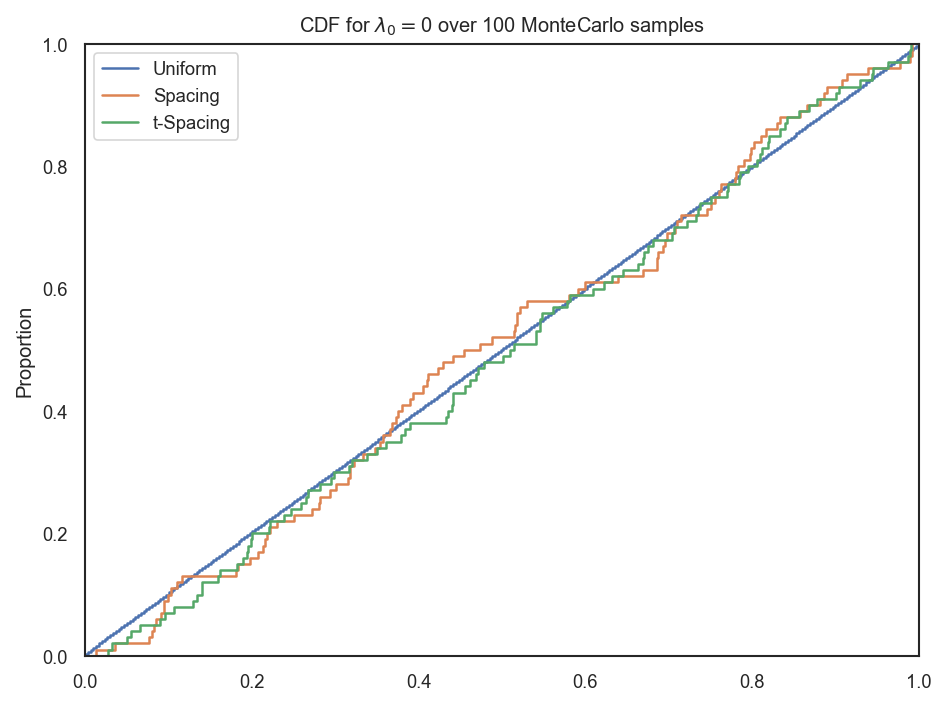

In [25]:
unif = np.linspace(0, 1, 300)

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the ECDFs
sb.ecdfplot(unif, label="Uniform", ax=ax)
sb.ecdfplot(stat, label="Spacing", ax=ax)
sb.ecdfplot(stat2, label="t-Spacing", ax=ax)

# Add legend and labels
ax.legend()
ax.set_title(r'CDF for $\lambda_0=$%s over %s MonteCarlo samples' % (lambda_0, repet))
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)

# Save the plot to a file and show it
name = "output_plot_CDF_pvalue.png"
plt.tight_layout()
plt.savefig(name)
plt.show()

### CDF of the distance $d(t_0, t_1)$

Under $\mathbb H_0$ ($\lambda_0=0$), the eigenvector $t_1$ is uniformly distributed on $\mathbb S^2$ and is independent of $t_0$. The CDF of $d(t_0,t_1)$ should therefore follow the uniform distribution.

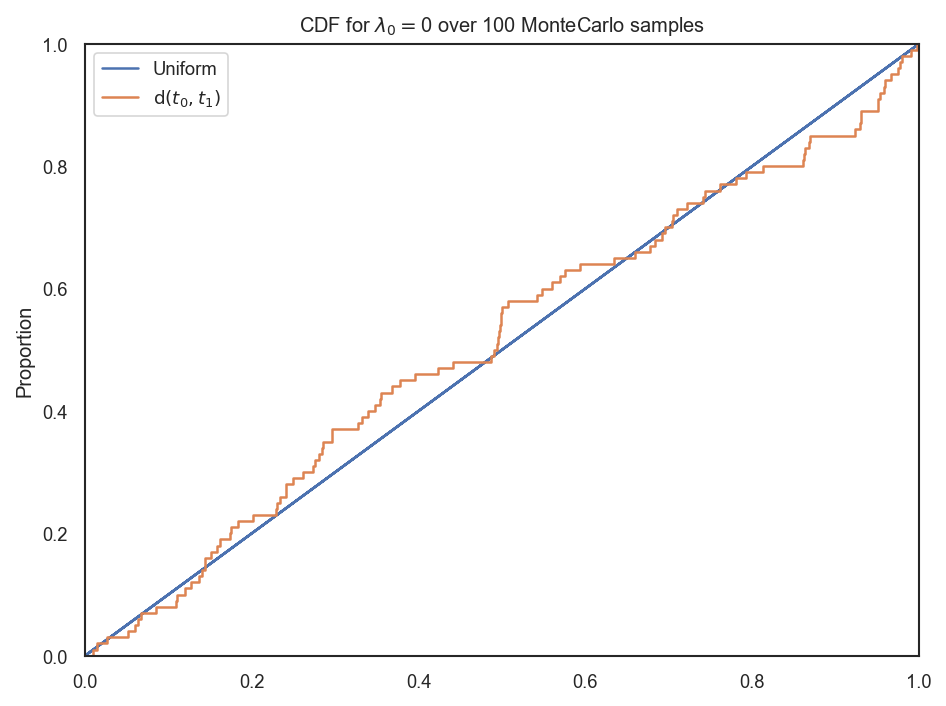

In [26]:
unif = np.linspace(0, 1, 3000)
unif_dist = cdf_dist_null(dist)
unif_dist2 = cdf_dist_null(dist2)

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the ECDFs
sb.ecdfplot(unif, label="Uniform", ax=ax)
sb.ecdfplot(unif_dist, label="$\mathrm{d}(t_0,t_1)$", ax=ax)

# Add legend and labels
ax.legend()
ax.set_title(r'CDF for $\lambda_0=$%s over %s MonteCarlo samples' % (lambda_0, repet))
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)

# Save the plot to a file and show it
name = "output_plot_CDF_dist_t0_t1.png"
plt.tight_layout()
plt.savefig(name)
plt.show()

### PDF of the distance $d(t_1, t_2)$

The distance between the first and second eigenvectors is expected to be close to the orthogonal case ($d\approx 1/2$) under $\mathbb H_0$. We display its empirical PDF with a KDE overlay.

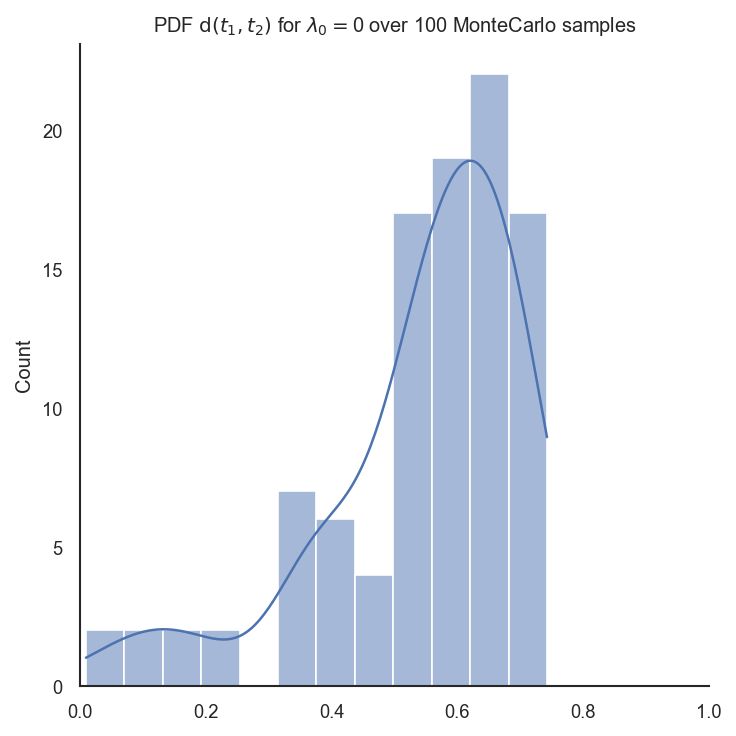

In [27]:
# Plot the PDF with KDE
sb.displot(unif_dist2, kde=True)
plt.title (r'PDF $\mathrm{d}(t_1,t_2)$ for $\lambda_0=$%s over %s MonteCarlo samples' %(lambda_0,repet))
plt.xlim((0,1))
plt.tight_layout()

# Save the plot to a file and show it
name = "output_plot_pdf_dist_t1_t2.png"
plt.tight_layout()
plt.savefig(name)
plt.show()

### Distribution of $\hat\sigma^2$

Under $\mathbb H_0$ with $\sigma=1$, the estimate $\hat\sigma^2$ follows a $\chi^2(\bar m)/\bar m$ distribution with $\bar m=7$ degrees of freedom. We overlay the empirical histogram of $\hat\sigma^2$ with the theoretical $\chi^2(7)/7$ density.

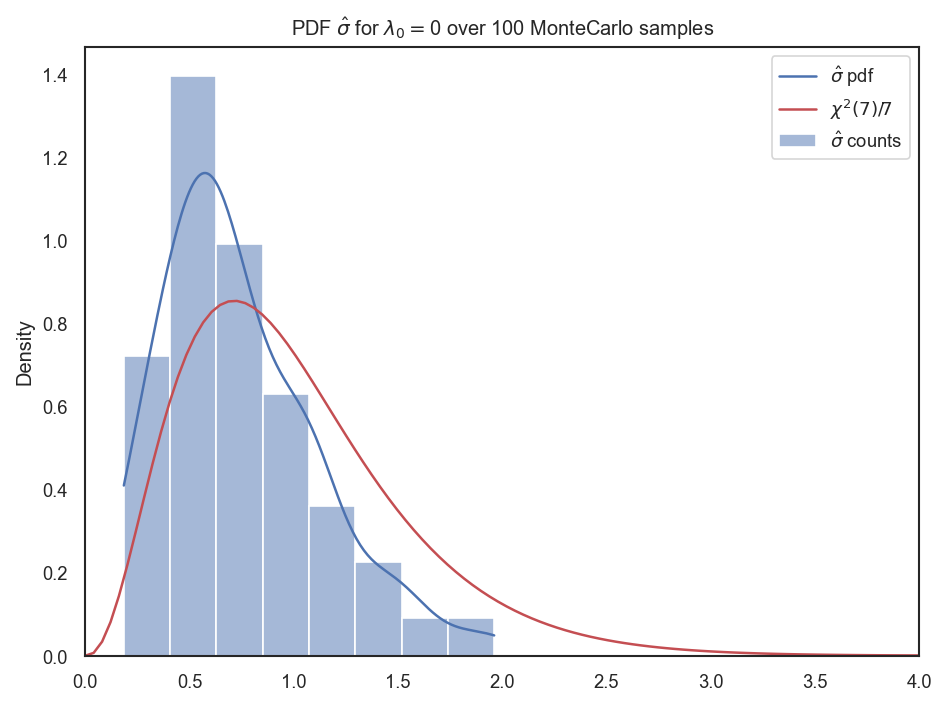

In [28]:
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the histogram with KDE and PDF
sigma_squared = sigma**2
ax = sb.histplot(sigma_squared, kde=True, stat='density', ax=ax)
grid_plot = np.linspace(0, 4, 100)
ax.plot(grid_plot, 7 * chi2.pdf(7 * grid_plot, df=7), 'r-')

# Add legend and labels
ax.legend([r'$\hat\sigma$ pdf', r'$\chi^2(7)/7$', r'$\hat\sigma$ counts'])
ax.set_title(r'PDF $\hat\sigma$ for $\lambda_0=$%s over %s MonteCarlo samples' % (lambda_0, repet))
ax.set_xlim(0, 4)

# Save the plot to a file and show it
name = "output_plot_sigma.png"
plt.tight_layout()
plt.savefig(name)
plt.show()